# Binarization - Titanic Dataset


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('2_Binarization_Titanic.csv')
df.head()

,survived,pclass,sex,age,fare
0,0,1,female,16.9,1.37
1,0,3,female,43.3,110.64
2,0,3,male,8.6,51.30
3,0,2,male,36.6,11.09
4,1,3,male,60.7,125.14


In [21]:
df['age'].describe()

count    200.000000
mean      39.570500
std       23.392901
min        1.900000
25%       17.875000
50%       39.500000
75%       60.800000
max       79.700000
Name: age, dtype: float64

In [22]:
df['is_adult'] = (df['age'] > 18).astype(int)
df[['age','is_adult']].head(10)

,age,is_adult
0,16.9,0
1,43.3,1
2,8.6,0
3,36.6,1
4,60.7,1
5,28.5,1
6,53.5,1
7,63.8,1
8,74.2,1
9,19.5,1


In [23]:
df['is_adult'].value_counts()

is_adult
1    149
0     51
Name: count, dtype: int64

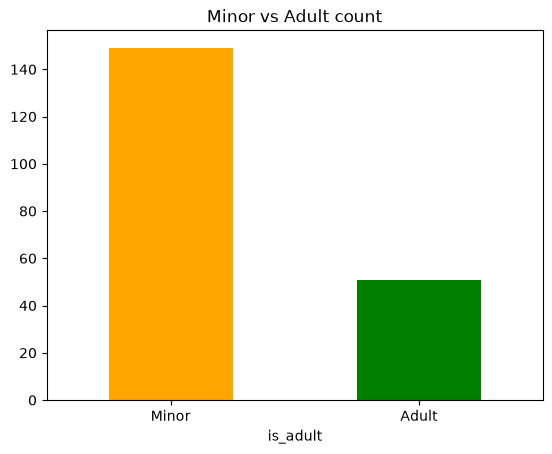

In [24]:
df['is_adult'].value_counts().plot(kind='bar', color=['orange','green'])
plt.title('Minor vs Adult count')
plt.xticks([0,1], ['Minor', 'Adult'], rotation=0)
plt.show()

In [25]:
from sklearn.preprocessing import Binarizer

bina = Binarizer(threshold=18)
df['is_adult_check'] = bina.fit_transform(df[['age']]).astype(int)
df[['age','is_adult','is_adult_check']].head()

,age,is_adult,is_adult_check
0,16.9,0,0
1,43.3,1,1
2,8.6,0,0
3,36.6,1,1
4,60.7,1,1


In [26]:
df['age_group'] = pd.cut(df['age'], bins=[0,12,18,60,100], labels=['Child','Teen','Adult','Senior'])
df[['age','age_group']].sample(10)

,age,age_group
194,17.2,Teen
74,77.3,Senior
147,76.5,Senior
185,61.4,Senior
178,28.6,Adult
76,25.6,Adult
62,48.9,Adult
73,44.4,Adult
48,63.4,Senior
63,61.4,Senior


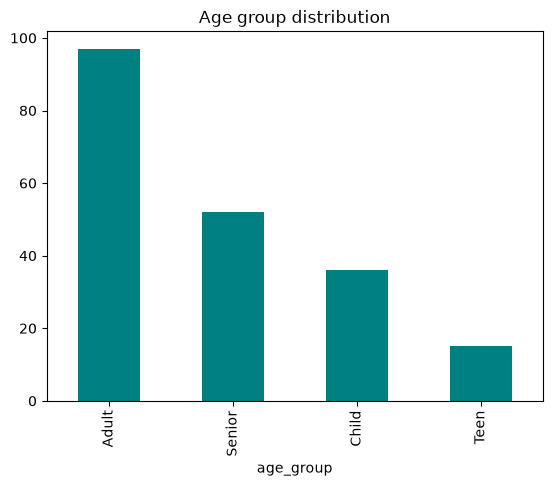

In [18]:
df['age_group'].value_counts().plot(kind='bar', color='teal')
plt.title('Age group distribution')
plt.show()